<a href="https://colab.research.google.com/github/Anshitha9286/ASSIGNMENT/blob/main/Weather_Temperature_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

UPLOAD ZIP FILE



In [1]:
from google.colab import files

uploaded = files.upload()

print("File uploaded successfully!")
print(list(uploaded.keys()))

Saving archive (2).zip to archive (2).zip
File uploaded successfully!
['archive (2).zip']


 EXTRACT ZIP FILE

In [2]:
import zipfile
import os

zip_filename = list(uploaded.keys())[0]

extract_path = "/content/weather_dataset"

with zipfile.ZipFile(zip_filename, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("ZIP file extracted successfully!")

print("\nFiles inside the extracted folder:")

for root, dirs, files_list in os.walk(extract_path):
    for file in files_list:
        print(os.path.join(root, file))

ZIP file extracted successfully!

Files inside the extracted folder:
/content/weather_dataset/weatherHistory.csv


IMPORT LIBRARIES

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score

import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.callbacks import EarlyStopping

print("Libraries imported successfully!")
print("TensorFlow version:", tf.__version__)

Libraries imported successfully!
TensorFlow version: 2.20.0


FIND CSV FILE

In [4]:
csv_files = []

for root, dirs, files_list in os.walk(extract_path):
    for file in files_list:
        if file.lower().endswith(".csv"):
            csv_files.append(os.path.join(root, file))

print("CSV files found:")

for file in csv_files:
    print(file)

CSV files found:
/content/weather_dataset/weatherHistory.csv


LOAD DATASET

In [5]:
file_path = csv_files[0]

df = pd.read_csv(file_path)

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)

Dataset loaded successfully!
Dataset shape: (96453, 12)


Display first 10 rows

In [7]:
display(df.head(10))

,Formatted Date,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Daily Summary
0,2006-04-01 00:00:00.000 +0200,Partly Cloudy,rain,9.472222,7.388889,0.89,14.1197,251.0,15.8263,0.0,1015.13,Partly cloudy throughout the day.
1,2006-04-01 01:00:00.000 +0200,Partly Cloudy,rain,9.355556,7.227778,0.86,14.2646,259.0,15.8263,0.0,1015.63,Partly cloudy throughout the day.
2,2006-04-01 02:00:00.000 +0200,Mostly Cloudy,rain,9.377778,9.377778,0.89,3.9284,204.0,14.9569,0.0,1015.94,Partly cloudy throughout the day.
3,2006-04-01 03:00:00.000 +0200,Partly Cloudy,rain,8.288889,5.944444,0.83,14.1036,269.0,15.8263,0.0,1016.41,Partly cloudy throughout the day.
4,2006-04-01 04:00:00.000 +0200,Mostly Cloudy,rain,8.755556,6.977778,0.83,11.0446,259.0,15.8263,0.0,1016.51,Partly cloudy throughout the day.
5,2006-04-01 05:00:00.000 +0200,Partly Cloudy,rain,9.222222,7.111111,0.85,13.9587,258.0,14.9569,0.0,1016.66,Partly cloudy throughout the day.
6,2006-04-01 06:00:00.000 +0200,Partly Cloudy,rain,7.733333,5.522222,0.95,12.3648,259.0,9.9820,0.0,1016.72,Partly cloudy throughout the day.
7,2006-04-01 07:00:00.000 +0200,Partly Cloudy,rain,8.772222,6.527778,0.89,14.1519,260.0,9.9820,0.0,1016.84,Partly cloudy throughout the day.
8,2006-04-01 08:00:00.000 +0200,Partly Cloudy,rain,10.822222,10.822222,0.82,11.3183,259.0,9.9820,0.0,1017.37,Partly cloudy throughout the day.
9,2006-04-01 09:00:00.000 +0200,Partly Cloudy,rain,13.772222,13.772222,0.72,12.5258,279.0,9.9820,0.0,1017.22,Partly cloudy throughout the day.


In [8]:
print("Column Names:")
print(df.columns.tolist())

Column Names:
['Formatted Date', 'Summary', 'Precip Type', 'Temperature (C)', 'Apparent Temperature (C)', 'Humidity', 'Wind Speed (km/h)', 'Wind Bearing (degrees)', 'Visibility (km)', 'Loud Cover', 'Pressure (millibars)', 'Daily Summary']


In [9]:
print("\nDataset Information:")
df.info()


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96453 entries, 0 to 96452
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Formatted Date            96453 non-null  object 
 1   Summary                   96453 non-null  object 
 2   Precip Type               95936 non-null  object 
 3   Temperature (C)           96453 non-null  float64
 4   Apparent Temperature (C)  96453 non-null  float64
 5   Humidity                  96453 non-null  float64
 6   Wind Speed (km/h)         96453 non-null  float64
 7   Wind Bearing (degrees)    96453 non-null  float64
 8   Visibility (km)           96453 non-null  float64
 9   Loud Cover                96453 non-null  float64
 10  Pressure (millibars)      96453 non-null  float64
 11  Daily Summary             96453 non-null  object 
dtypes: float64(8), object(4)
memory usage: 8.8+ MB


In [10]:
print("\nStatistical Summary:")
display(df.describe())


Statistical Summary:


,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars)
count,96453.000000,96453.000000,96453.000000,96453.000000,96453.000000,96453.000000,96453.0,96453.000000
mean,11.932678,10.855029,0.734899,10.810640,187.509232,10.347325,0.0,1003.235956
std,9.551546,10.696847,0.195473,6.913571,107.383428,4.192123,0.0,116.969906
min,-21.822222,-27.716667,0.000000,0.000000,0.000000,0.000000,0.0,0.000000
25%,4.688889,2.311111,0.600000,5.828200,116.000000,8.339800,0.0,1011.900000
50%,12.000000,12.000000,0.780000,9.965900,180.000000,10.046400,0.0,1016.450000
75%,18.838889,18.838889,0.890000,14.135800,290.000000,14.812000,0.0,1021.090000
max,39.905556,39.344444,1.000000,63.852600,359.000000,16.100000,0.0,1046.380000


CLEAN COLUMN NAMES

In [11]:
df.columns = df.columns.str.strip()

print(df.columns.tolist())

['Formatted Date', 'Summary', 'Precip Type', 'Temperature (C)', 'Apparent Temperature (C)', 'Humidity', 'Wind Speed (km/h)', 'Wind Bearing (degrees)', 'Visibility (km)', 'Loud Cover', 'Pressure (millibars)', 'Daily Summary']


SELECT REQUIRED COLUMNS

In [12]:
df = df[
    [
        'Formatted Date',
        'Temperature (C)',
        'Humidity',
        'Wind Speed (km/h)'
    ]
].copy()

print(df.head())

                  Formatted Date  Temperature (C)  Humidity  Wind Speed (km/h)
0  2006-04-01 00:00:00.000 +0200         9.472222      0.89            14.1197
1  2006-04-01 01:00:00.000 +0200         9.355556      0.86            14.2646
2  2006-04-01 02:00:00.000 +0200         9.377778      0.89             3.9284
3  2006-04-01 03:00:00.000 +0200         8.288889      0.83            14.1036
4  2006-04-01 04:00:00.000 +0200         8.755556      0.83            11.0446


RENAME COLUMNS

In [13]:
df.rename(
    columns={
        'Formatted Date': 'Date',
        'Temperature (C)': 'Temperature',
        'Wind Speed (km/h)': 'Wind Speed'
    },
    inplace=True
)

print(df.columns.tolist())

['Date', 'Temperature', 'Humidity', 'Wind Speed']


CONVERT DATE

In [14]:
df['Date'] = pd.to_datetime(
    df['Date'],
    errors='coerce',
    utc=True
)

print(df.head())

                       Date  Temperature  Humidity  Wind Speed
0 2006-03-31 22:00:00+00:00     9.472222      0.89     14.1197
1 2006-03-31 23:00:00+00:00     9.355556      0.86     14.2646
2 2006-04-01 00:00:00+00:00     9.377778      0.89      3.9284
3 2006-04-01 01:00:00+00:00     8.288889      0.83     14.1036
4 2006-04-01 02:00:00+00:00     8.755556      0.83     11.0446


CHECK MISSING VALUES

In [15]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
Date           0
Temperature    0
Humidity       0
Wind Speed     0
dtype: int64


In [16]:
missing_percentage = (
    df.isnull().sum() / len(df)
) * 100

print("\nMissing Value Percentage:")
print(missing_percentage)


Missing Value Percentage:
Date           0.0
Temperature    0.0
Humidity       0.0
Wind Speed     0.0
dtype: float64


HANDLE MISSING VALUES

In [17]:
numeric_columns = [
    'Temperature',
    'Humidity',
    'Wind Speed'
]

for col in numeric_columns:

    df[col] = pd.to_numeric(
        df[col],
        errors='coerce'
    )

    df[col] = df[col].interpolate(
        method='linear'
    )

    df[col] = df[col].bfill()
    df[col] = df[col].ffill()

print("Missing values after treatment:")
print(df.isnull().sum())

Missing values after treatment:
Date           0
Temperature    0
Humidity       0
Wind Speed     0
dtype: int64


CONVERT HOURLY DATA TO DAILY DATA

In [18]:
df['Date'] = df['Date'].dt.date

daily_df = df.groupby('Date').agg({
    'Temperature': 'mean',
    'Humidity': 'mean',
    'Wind Speed': 'mean'
}).reset_index()

daily_df['Date'] = pd.to_datetime(
    daily_df['Date']
)

daily_df = daily_df.sort_values(
    'Date'
).reset_index(drop=True)

print("Daily dataset shape:", daily_df.shape)

display(daily_df.head(10))

Daily dataset shape: (4019, 4)


,Date,Temperature,Humidity,Wind Speed
0,2005-12-31,0.577778,0.890000,17.114300
1,2006-01-01,4.075000,0.817083,21.229192
2,2006-01-02,5.263194,0.847083,17.824713
3,2006-01-03,2.340509,0.897083,7.726658
4,2006-01-04,2.251852,0.906667,12.152817
5,2006-01-05,2.703935,0.951250,8.991179
6,2006-01-06,2.550463,0.945833,5.729588
7,2006-01-07,0.877083,0.935833,6.589596
8,2006-01-08,-1.231713,0.868750,5.397525
9,2006-01-09,-1.693287,0.792500,5.113762


TEMPERATURE TREND

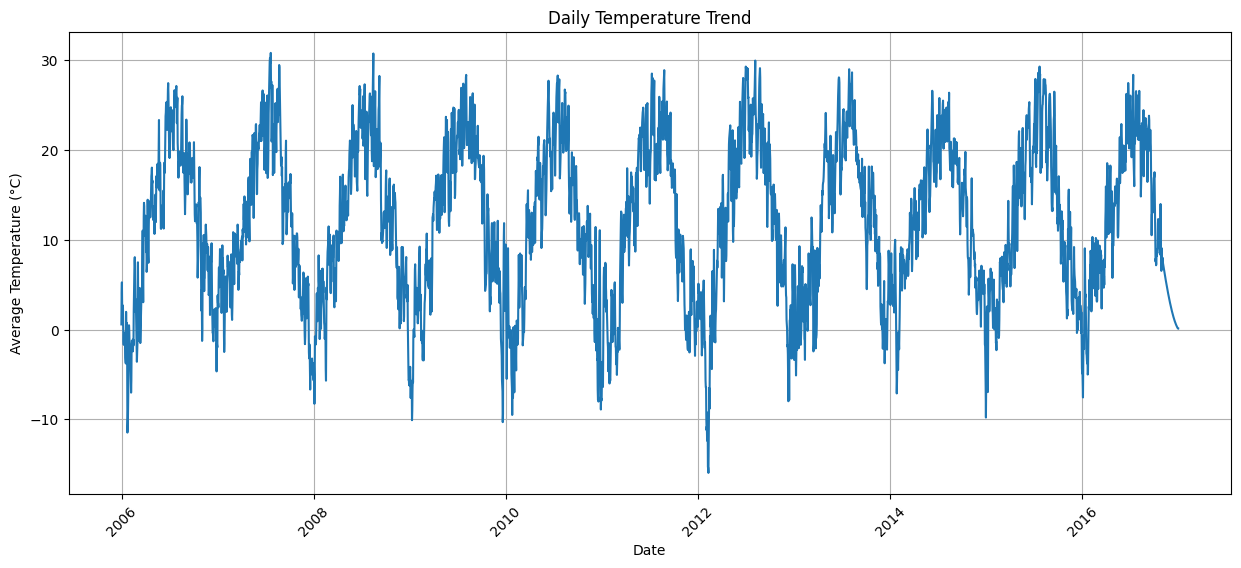

In [19]:
plt.figure(figsize=(15, 6))

plt.plot(
    daily_df['Date'],
    daily_df['Temperature']
)

plt.title('Daily Temperature Trend')
plt.xlabel('Date')
plt.ylabel('Average Temperature (°C)')

plt.xticks(rotation=45)

plt.grid(True)

plt.show()

FINAL DATA CHECK

In [20]:
print("Final Dataset:")
display(daily_df.head())

print("\nDataset Shape:")
print(daily_df.shape)

print("\nMissing Values:")
print(daily_df.isnull().sum())

Final Dataset:


,Date,Temperature,Humidity,Wind Speed
0,2005-12-31,0.577778,0.890000,17.114300
1,2006-01-01,4.075000,0.817083,21.229192
2,2006-01-02,5.263194,0.847083,17.824713
3,2006-01-03,2.340509,0.897083,7.726658
4,2006-01-04,2.251852,0.906667,12.152817



Dataset Shape:
(4019, 4)

Missing Values:
Date           0
Temperature    0
Humidity       0
Wind Speed     0
dtype: int64


 SELECT FEATURES

In [22]:
features = [
    'Temperature',
    'Humidity',
    'Wind Speed'
]

data = daily_df[features].copy()

print("Features selected:")
print(features)

print("\nData shape:")
print(data.shape)

display(data.head())

Features selected:
['Temperature', 'Humidity', 'Wind Speed']

Data shape:
(4019, 3)


,Temperature,Humidity,Wind Speed
0,0.577778,0.890000,17.114300
1,4.075000,0.817083,21.229192
2,5.263194,0.847083,17.824713
3,2.340509,0.897083,7.726658
4,2.251852,0.906667,12.152817


TRAIN / VALIDATION / TEST SPLIT

In [23]:
n = len(data)

train_end = int(n * 0.70)
validation_end = int(n * 0.85)

train_data = data.iloc[:train_end]
validation_data = data.iloc[train_end:validation_end]
test_data = data.iloc[validation_end:]

print("Training samples:", len(train_data))
print("Validation samples:", len(validation_data))
print("Testing samples:", len(test_data))

Training samples: 2813
Validation samples: 603
Testing samples: 603


NORMALIZATION

In [24]:
scaler = MinMaxScaler()

scaler.fit(train_data)

scaled_data = scaler.transform(data)

print("Normalization completed!")

print("\nFirst 5 scaled rows:")
print(scaled_data[:5])

Normalization completed!

First 5 scaled rows:
[[0.35354845 0.84946237 0.41866042]
 [0.42831832 0.74492234 0.53358314]
 [0.45372167 0.78793309 0.43850117]
 [0.39123528 0.85961768 0.15647775]
 [0.3893398  0.87335723 0.28009368]]


CREATE TIME-SERIES SEQUENCES

In [25]:
sequence_length = 7

X = []
y = []

for i in range(
    sequence_length,
    len(scaled_data)
):

    # Previous 7 days
    X.append(
        scaled_data[
            i-sequence_length:i
        ]
    )

    # Next day's temperature
    y.append(
        scaled_data[i, 0]
    )

X = np.array(X)
y = np.array(y)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (4012, 7, 3)
y shape: (4012,)


SPLIT SEQUENCES

In [26]:
total_samples = len(X)

train_end_seq = int(
    total_samples * 0.70
)

validation_end_seq = int(
    total_samples * 0.85
)

X_train = X[:train_end_seq]
y_train = y[:train_end_seq]

X_val = X[
    train_end_seq:validation_end_seq
]

y_val = y[
    train_end_seq:validation_end_seq
]

X_test = X[
    validation_end_seq:
]

y_test = y[
    validation_end_seq:
]

print("Training:")
print(X_train.shape, y_train.shape)

print("\nValidation:")
print(X_val.shape, y_val.shape)

print("\nTesting:")
print(X_test.shape, y_test.shape)

Training:
(2808, 7, 3) (2808,)

Validation:
(602, 7, 3) (602,)

Testing:
(602, 7, 3) (602,)


BUILD SIMPLE RNN MODEL

In [27]:
model = Sequential()

model.add(
    SimpleRNN(
        units=64,
        activation='tanh',
        input_shape=(
            X_train.shape[1],
            X_train.shape[2]
        )
    )
)

model.add(
    Dropout(0.2)
)

model.add(
    Dense(1)
)

model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 64)             │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,417 (17.25 KB)

 Trainable params: 4,417 (17.25 KB)

 Non-trainable params: 0 (0.00 B)

COMPILE MODEL

In [28]:
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

print("Model compiled successfully!")

Model compiled successfully!


TRAIN MODEL

In [29]:
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train,
    validation_data=(
        X_val,
        y_val
    ),
    epochs=100,
    batch_size=32,
    callbacks=[
        early_stopping
    ],
    verbose=1
)

Epoch 1/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0849 - mae: 0.2051 - val_loss: 0.0082 - val_mae: 0.0694
Epoch 2/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0185 - mae: 0.1066 - val_loss: 0.0045 - val_mae: 0.0534
Epoch 3/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0116 - mae: 0.0855 - val_loss: 0.0034 - val_mae: 0.0456
Epoch 4/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0089 - mae: 0.0750 - val_loss: 0.0029 - val_mae: 0.0422
Epoch 5/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0077 - mae: 0.0692 - val_loss: 0.0029 - val_mae: 0.0426
Epoch 6/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0074 - mae: 0.0679 - val_loss: 0.0035 - val_mae: 0.0474
Epoch 7/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0069 - mae: 0.0663 - val_loss: 0.0024 - val_mae: 0.0387
Epoch 8/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0061 - mae: 0.0621 - val_loss: 0.0023 - val_mae: 0.0381
Epoch 9/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.005

TRAINING VS VALIDATION LOSS

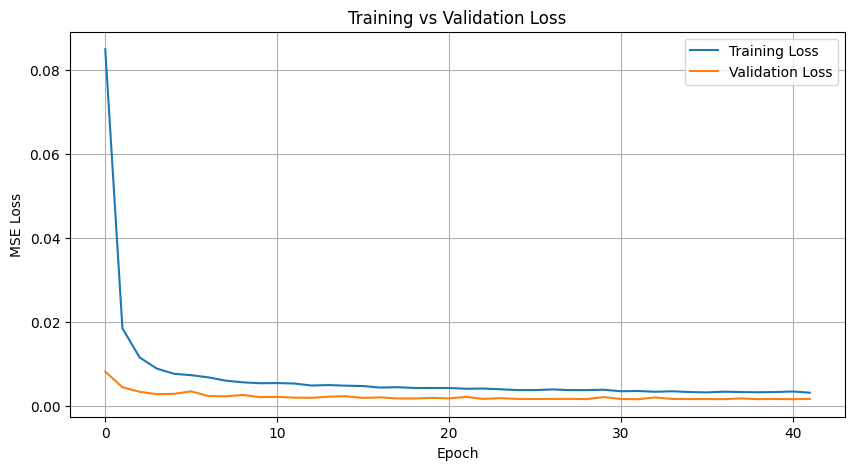

In [30]:
plt.figure(figsize=(10, 5))

plt.plot(
    history.history['loss'],
    label='Training Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)

plt.title(
    'Training vs Validation Loss'
)

plt.xlabel('Epoch')
plt.ylabel('MSE Loss')

plt.legend()
plt.grid(True)

plt.show()

TEST PREDICTIONS

In [31]:
y_pred_scaled = model.predict(
    X_test
)

print(
    "Prediction shape:",
    y_pred_scaled.shape
)

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
Prediction shape: (602, 1)


INVERSE TRANSFORM

In [32]:
def inverse_temperature(values):

    dummy = np.zeros(
        (len(values), 3)
    )

    dummy[:, 0] = values.flatten()

    original = scaler.inverse_transform(
        dummy
    )

    return original[:, 0]


actual_temperature = inverse_temperature(
    y_test
)

predicted_temperature = inverse_temperature(
    y_pred_scaled
)

print("Actual temperatures:")
print(actual_temperature[:5])

print("\nPredicted temperatures:")
print(predicted_temperature[:5])

Actual temperatures:
[17.72083333 14.63101852 16.5275463  20.22013889 18.00185185]

Predicted temperatures:
[18.7130115  16.86412847 14.84096007 17.84296185 20.3593594 ]


MODEL EVALUATION

In [33]:
rmse = np.sqrt(
    mean_squared_error(
        actual_temperature,
        predicted_temperature
    )
)

mae = mean_absolute_error(
    actual_temperature,
    predicted_temperature
)

r2 = r2_score(
    actual_temperature,
    predicted_temperature
)

print("================================")
print("       MODEL PERFORMANCE")
print("================================")

print(f"RMSE : {rmse:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"R²   : {r2:.4f}")

       MODEL PERFORMANCE
RMSE : 1.9700
MAE  : 1.5009
R²   : 0.9458


ACTUAL VS PREDICTED

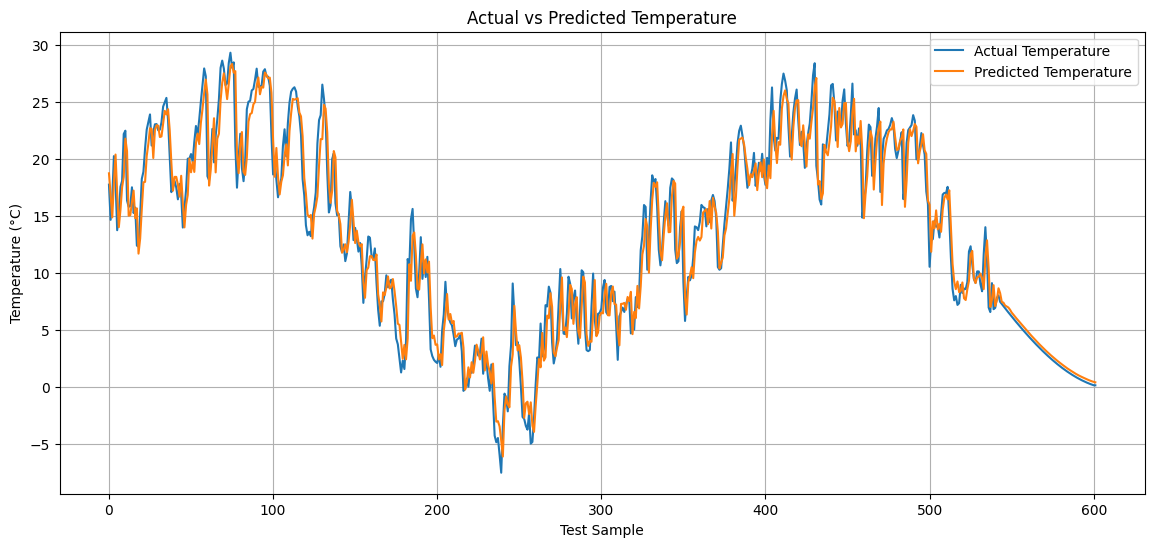

In [34]:
plt.figure(figsize=(14, 6))

plt.plot(
    actual_temperature,
    label='Actual Temperature'
)

plt.plot(
    predicted_temperature,
    label='Predicted Temperature'
)

plt.title(
    'Actual vs Predicted Temperature'
)

plt.xlabel('Test Sample')
plt.ylabel('Temperature (°C)')

plt.legend()
plt.grid(True)

plt.show()

TEST DATES

In [35]:
test_start_index = (
    validation_end_seq
    + sequence_length
)

test_dates = daily_df[
    'Date'
].iloc[
    test_start_index:
    test_start_index + len(y_test)
].reset_index(drop=True)

print(test_dates.head())

0   2015-05-10
1   2015-05-11
2   2015-05-12
3   2015-05-13
4   2015-05-14
Name: Date, dtype: datetime64[ns]


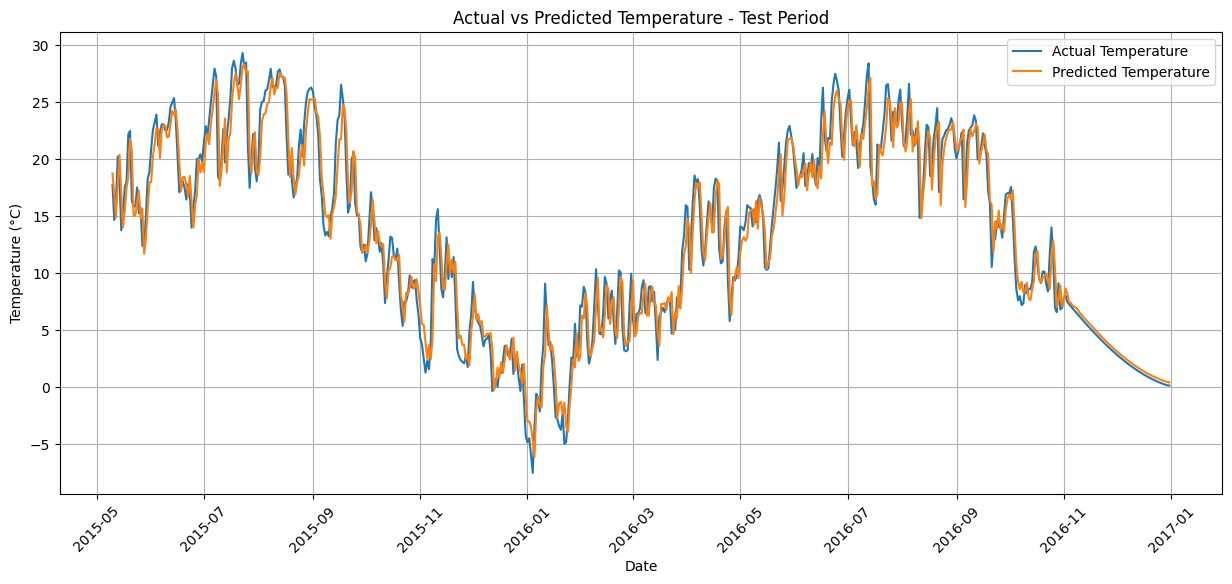

In [36]:
plt.figure(figsize=(15, 6))

plt.plot(
    test_dates,
    actual_temperature,
    label='Actual Temperature'
)

plt.plot(
    test_dates,
    predicted_temperature,
    label='Predicted Temperature'
)

plt.title(
    'Actual vs Predicted Temperature - Test Period'
)

plt.xlabel('Date')
plt.ylabel('Temperature (°C)')

plt.xticks(rotation=45)

plt.legend()
plt.grid(True)

plt.show()

FORECAST NEXT 7 DAYS

In [37]:
last_sequence = scaled_data[
    -sequence_length:
].copy()

future_predictions_scaled = []

for day in range(7):

    # Reshape input for RNN
    current_input = last_sequence.reshape(
        1,
        sequence_length,
        3
    )

    # Predict next day's temperature
    next_temperature = model.predict(
        current_input,
        verbose=0
    )[0][0]

    future_predictions_scaled.append(
        next_temperature
    )

    # Keep the latest humidity
    # and wind speed because future
    # values are unknown.

    next_day_features = np.array([
        next_temperature,
        last_sequence[-1, 1],
        last_sequence[-1, 2]
    ])

    # Remove oldest day and add
    # newly predicted day
    last_sequence = np.vstack([
        last_sequence[1:],
        next_day_features
    ])

future_predictions_scaled = np.array(
    future_predictions_scaled
)

future_predictions = inverse_temperature(
    future_predictions_scaled
)

print("Next 7 Days Predictions:")
print(future_predictions)

Next 7 Days Predictions:
[0.37036737 0.59988935 0.77862699 0.91494957 1.02878498 1.13442397
 1.2361822 ]


CREATE FUTURE DATES

In [38]:
last_date = daily_df[
    'Date'
].iloc[-1]

future_dates = pd.date_range(
    start=last_date + pd.Timedelta(days=1),
    periods=7,
    freq='D'
)

forecast_df = pd.DataFrame({
    'Date': future_dates,
    'Predicted Temperature (°C)':
        future_predictions
})

forecast_df[
    'Predicted Temperature (°C)'
] = forecast_df[
    'Predicted Temperature (°C)'
].round(2)

display(forecast_df)

,Date,Predicted Temperature (°C)
0,2017-01-01,0.37
1,2017-01-02,0.60
2,2017-01-03,0.78
3,2017-01-04,0.91
4,2017-01-05,1.03
5,2017-01-06,1.13
6,2017-01-07,1.24


7-DAY FORECAST VISUALIZATION

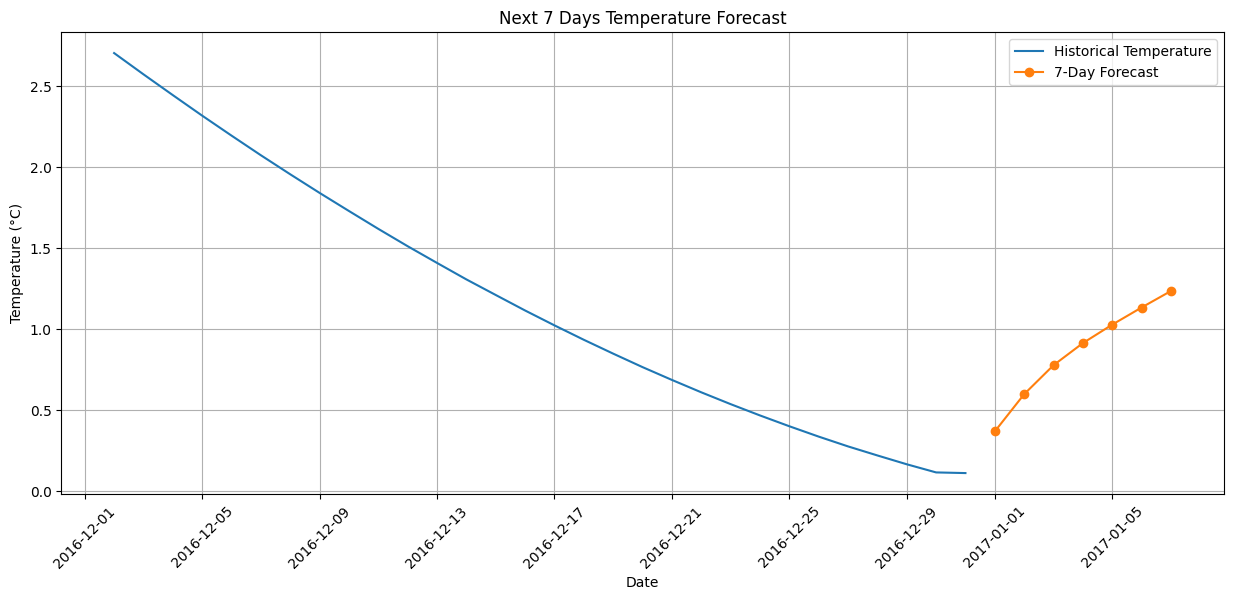

In [39]:
recent_days = 30

recent_data = daily_df.tail(
    recent_days
)

plt.figure(figsize=(15, 6))

plt.plot(
    recent_data['Date'],
    recent_data['Temperature'],
    label='Historical Temperature'
)

plt.plot(
    future_dates,
    future_predictions,
    marker='o',
    label='7-Day Forecast'
)

plt.title(
    'Next 7 Days Temperature Forecast'
)

plt.xlabel('Date')
plt.ylabel('Temperature (°C)')

plt.xticks(rotation=45)

plt.legend()
plt.grid(True)

plt.show()

FINAL RESULTS

In [40]:
print("=" * 50)
print("       SIMPLE RNN WEATHER FORECASTING")
print("=" * 50)

print("\nModel Configuration")
print("-" * 30)
print("Sequence Length : 7 days")
print("RNN Units       : 64")
print("Optimizer       : Adam")
print("Loss Function   : MSE")
print("Metric          : MAE")
print("Batch Size      : 32")
print("Maximum Epochs  : 100")

print("\nModel Performance")
print("-" * 30)
print(f"RMSE            : {rmse:.4f}")
print(f"MAE             : {mae:.4f}")
print(f"R² Score        : {r2:.4f}")

print("\n7-Day Temperature Forecast")
print("-" * 30)

display(forecast_df)

       SIMPLE RNN WEATHER FORECASTING

Model Configuration
------------------------------
Sequence Length : 7 days
RNN Units       : 64
Optimizer       : Adam
Loss Function   : MSE
Metric          : MAE
Batch Size      : 32
Maximum Epochs  : 100

Model Performance
------------------------------
RMSE            : 1.9700
MAE             : 1.5009
R² Score        : 0.9458

7-Day Temperature Forecast
------------------------------


,Date,Predicted Temperature (°C)
0,2017-01-01,0.37
1,2017-01-02,0.60
2,2017-01-03,0.78
3,2017-01-04,0.91
4,2017-01-05,1.03
5,2017-01-06,1.13
6,2017-01-07,1.24


A SimpleRNN model was developed to predict the next day’s temperature using the previous 7 days of temperature, humidity, and wind speed data. The data was cleaned, converted into daily observations, and normalized using MinMaxScaler. The model was trained using the Adam optimizer and MSE loss. Its performance was evaluated using RMSE, MAE, and R². The trained model was also used to forecast temperatures for the next 7 days. The results show that SimpleRNN can learn patterns from weather data and provide short-term temperature predictions.
